# Bank Marketing Intelligence System

## 03 — Model Validation, Tuning and Explainability

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, average_precision_score

In [54]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

X = df.drop(columns="y")
y = df["y"].map({
    "no": 0,
    "yes": 1
})

In [55]:
# Recreating  the split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
# Recreating preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [57]:
# Random forest pipeline

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [58]:
# Cross validation 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

In [59]:
# Result 

cv_summary = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_pr_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_pr_auc"].std()
    ]
})

cv_summary

,Metric,Mean,Std
0,accuracy,0.899193,0.003094
1,precision,0.559424,0.011179
2,recall,0.650443,0.022980
3,f1,0.601402,0.014905
4,roc_auc,0.930440,0.002481
5,pr_auc,0.604513,0.018561


In [61]:
# Hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__n_estimators": [200, 300, 400, 500, 600],
    "model__max_depth": [10, 15, 20, 25, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 5],
    "model__max_features": ["sqrt", "log2", None]
}

In [31]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum sco

In [62]:
print("Best PR-AUC:", random_search.best_score_)
print("\nBest Parameters:")
print(random_search.best_params_)

best_rf = random_search.best_estimator_

Best PR-AUC: 0.6117385893399422

Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [63]:
best_rf = random_search.best_estimator_

tuned_proba = best_rf.predict_proba(X_test)[:, 1]

In [64]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [65]:
from sklearn.base import clone

threshold_model = clone(best_rf)
threshold_model.fit(X_train_model, y_train_model)

val_proba = threshold_model.predict_proba(X_val)[:, 1]

In [79]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    
    val_pred = (val_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_val, val_pred, zero_division=0),
        "Recall": recall_score(y_val, val_pred, zero_division=0),
        "F1": f1_score(y_val, val_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.248665,0.990544,0.397533
1,0.15,0.288188,0.983452,0.445754
2,0.20,0.320608,0.972813,0.482274
3,0.25,0.349741,0.957447,0.512334
4,0.30,0.379801,0.946809,0.542132
5,0.35,0.412013,0.924350,0.569971
6,0.40,0.446512,0.907801,0.598597
7,0.45,0.470889,0.869976,0.611042
8,0.50,0.494631,0.816785,0.616139
9,0.55,0.525723,0.773050,0.625837


## Threshold Optimization

The default classification threshold of 0.5 is not necessarily optimal for an imbalanced marketing classification problem.

A range of probability thresholds was evaluated on a validation set to examine the trade-off between precision and recall.

The final threshold should not be selected solely on accuracy. Instead, the choice should reflect the business cost of false positives (unnecessary marketing contacts) versus false negatives (missed potential subscribers).

The test set is kept untouched until the final model and threshold have been selected.

In [68]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.550000
Precision    0.525723
Recall       0.773050
F1           0.625837
Name: 9, dtype: float64

## Threshold Selection

The default classification threshold of 0.50 was compared with thresholds ranging from 0.10 to 0.90.

The threshold of 0.55 produced the highest validation F1 score:

- Precision: 52.57%
- Recall: 77.31%
- F1: 62.58%

Compared with the default threshold of 0.50, the 0.55 threshold slightly improves precision and F1 while reducing recall.

Therefore, 0.55 is selected as the current operating threshold for the model, subject to final evaluation on the untouched test set.

This threshold represents a business trade-off rather than a universally optimal value. A different threshold may be appropriate depending on the relative costs of false positives and false negatives.

## Now by Removing duration

In [69]:
X_train_no_duration = X_train.drop(columns=["duration"])
X_test_no_duration = X_test.drop(columns=["duration"])

print("With duration:", X_train.shape)
print("Without duration:", X_train_no_duration.shape)

With duration: (36168, 16)
Without duration: (36168, 15)


In [70]:
numerical_features_no_duration = X_train_no_duration.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_no_duration = X_train_no_duration.select_dtypes(
    include=["object", "string"]
).columns.tolist()

In [71]:
numerical_pipeline_no_duration = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_no_duration = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_no_duration = ColumnTransformer([
    ("num", numerical_pipeline_no_duration, numerical_features_no_duration),
    ("cat", categorical_pipeline_no_duration, categorical_features_no_duration)
])

In [75]:
realistic_rf = Pipeline([
    ("preprocessor", preprocessor_no_duration),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

realistic_rf.fit(
    X_train_no_duration,
    y_train
)

realistic_pred = realistic_rf.predict(X_test_no_duration)

realistic_proba = realistic_rf.predict_proba(
    X_test_no_duration
)[:, 1]

In [80]:
print("Accuracy :", accuracy_score(y_test, realistic_pred))
print("Precision:", precision_score(y_test, realistic_pred))
print("Recall   :", recall_score(y_test, realistic_pred))
print("F1 Score :", f1_score(y_test, realistic_pred))
print("ROC-AUC  :", roc_auc_score(y_test, realistic_proba))
print("PR-AUC   :", average_precision_score(y_test, realistic_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, realistic_pred))

Accuracy : 0.8611080393674665
Precision: 0.4263392857142857
Recall   : 0.5415879017013232
F1 Score : 0.47710241465445463
ROC-AUC  : 0.8011460524400075
PR-AUC   : 0.4525188150686866

Confusion Matrix:
[[7214  771]
 [ 485  573]]


## Tune threshold for realistic model

In [81]:
X_train_real, X_val_real, y_train_real, y_val_real = train_test_split(
    X_train_no_duration,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [82]:
from sklearn.base import clone

realistic_threshold_model = clone(realistic_rf)

realistic_threshold_model.fit(
    X_train_real,
    y_train_real
)

realistic_val_proba = realistic_threshold_model.predict_proba(
    X_val_real
)[:, 1]

In [83]:
realistic_threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    val_pred = (
        realistic_val_proba >= threshold
    ).astype(int)

    realistic_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val_real,
            val_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val_real,
            val_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val_real,
            val_pred,
            zero_division=0
        )
    })

realistic_threshold_df = pd.DataFrame(
    realistic_threshold_results
)

realistic_threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.130853,0.964539,0.230443
1,0.15,0.149403,0.917258,0.256954
2,0.20,0.176781,0.871158,0.293918
3,0.25,0.208487,0.801418,0.330893
4,0.30,0.247231,0.738771,0.370480
5,0.35,0.290274,0.687943,0.408278
6,0.40,0.337484,0.640662,0.442088
7,0.45,0.381997,0.596927,0.465867
8,0.50,0.418882,0.540189,0.471864
9,0.55,0.459459,0.502364,0.479955


In [84]:
realistic_best_threshold = realistic_threshold_df.loc[
    realistic_threshold_df["F1"].idxmax()
]

realistic_best_threshold

Threshold    0.550000
Precision    0.459459
Recall       0.502364
F1           0.479955
Name: 9, dtype: float64

## Explainability

In [85]:
# get the trained Random Forest:
rf_model = realistic_rf.named_steps["model"]

# Get the preprocessing component:
preprocessor_fitted = realistic_rf.named_steps["preprocessor"]

# Get transformed feature names:
feature_names = preprocessor_fitted.get_feature_names_out()

# get importance:
importances = rf_model.feature_importances_

# Create a DataFrame:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

# View top 20
feature_importance_df.head(20)

,Feature,Importance
1,num__balance,0.136510
0,num__age,0.120870
2,num__day,0.108653
3,num__campaign,0.059470
48,cat__poutcome_success,0.049828
4,num__pdays,0.046836
33,cat__contact_unknown,0.039000
5,num__previous,0.027049
27,cat__housing_no,0.024080
28,cat__housing_yes,0.023995


In [90]:
def get_original_feature_name(feature_name):
    
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    
    if feature_name.startswith("cat__"):
        feature_name = feature_name.replace("cat__", "")
        
        for column in categorical_features_no_duration:
            if feature_name.startswith(column + "_"):
                return column
    
    return feature_name

feature_importance_df["Original_Feature"] = (
    feature_importance_df["Feature"]
    .apply(get_original_feature_name)
)

original_importance = (
    feature_importance_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

original_importance

,Original_Feature,Importance
0,balance,0.136510
1,month,0.126751
2,age,0.120870
3,day,0.108653
4,job,0.080733
5,poutcome,0.079043
6,contact,0.068311
7,campaign,0.059470
8,housing,0.048075
9,pdays,0.046836


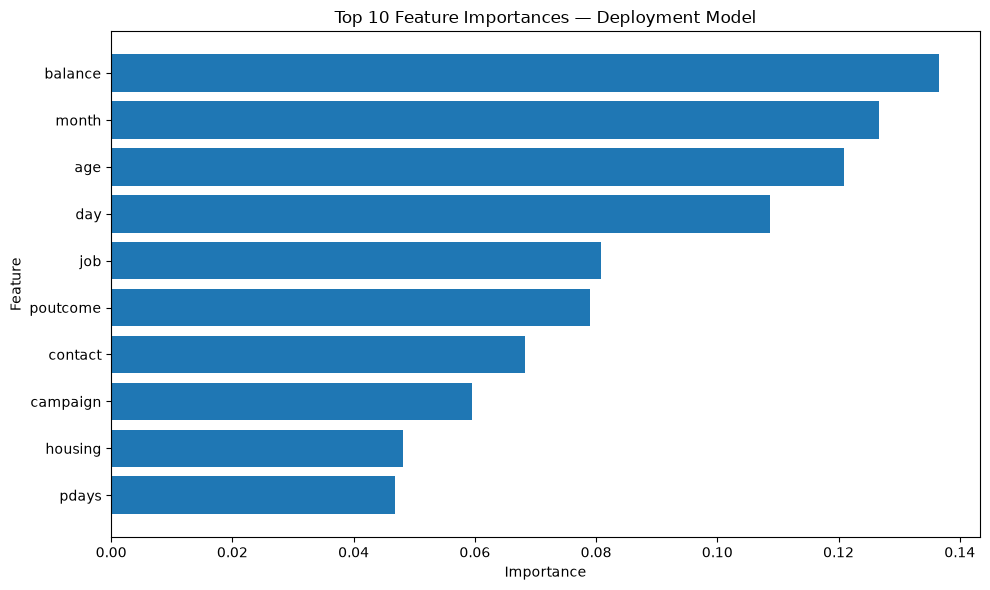

In [91]:
import matplotlib.pyplot as plt

top_features = original_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Original_Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Deployment Model")

plt.tight_layout()
plt.show()

# Day 3 — Final Findings

## Model Validation

Five-fold stratified cross-validation showed that the Random Forest model provides stable performance, achieving an average ROC-AUC of approximately 0.930 with a standard deviation of 0.0025.

## Hyperparameter Tuning

Randomized hyperparameter search improved cross-validation PR-AUC from approximately 0.605 to 0.612. The improvement was relatively small, indicating that the baseline Random Forest was already reasonably strong.

## Threshold Optimization

For the model containing `duration`, a threshold of 0.55 produced the highest validation F1 score of approximately 0.626.

For the deployment-realistic model without `duration`, the best validation F1 was approximately 0.480 at a threshold of 0.55.

## Duration Analysis

Removing `duration` caused a substantial reduction in performance:

- ROC-AUC decreased from approximately 0.930 to 0.801.
- PR-AUC decreased from approximately 0.617 to 0.453.
- F1 decreased from approximately 0.607 to 0.477 at the default threshold.

This demonstrates that `duration` contains strong predictive information. However, it is not suitable for pre-call targeting because it is only available after the contact process has started.

Therefore, the deployment model excludes `duration`, even though this results in lower predictive performance.

## Feature Importance

For the deployment-realistic model, the most important original features were balance, month, age, day, job, poutcome, contact, campaign, housing and pdays.

Feature importance indicates which variables the Random Forest relies on for its predictions. It does not establish causal relationships between the features and subscription outcomes.

### Save the model

In [95]:
# Training the model

final_model = clone(realistic_rf)

final_model.fit(
    X_train_no_duration,
    y_train
)

print("Final model trained successfully.")

Final model trained successfully.


In [ ]:
# Saving model

import joblib

model_artifact = {
    "model": final_model,
    "threshold": 0.55,
    "features": X_train_no_duration.columns.tolist()
}

joblib.dump(
    model_artifact,
    "../models/bank_marketing_model.joblib"
)

['../models/bank_marketing_model.joblib']

In [ ]:
# Verify

loaded_artifact = joblib.load(
    "../models/bank_marketing_model.joblib"
)

print(loaded_artifact.keys())
print("Threshold:", loaded_artifact["threshold"])
print("Features:", loaded_artifact["features"])

dict_keys(['model', 'threshold', 'features'])
Threshold: 0.55
Features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']
